In [183]:
from py_files.setup import *
setup_notebook()

# %pip install git+https://github.com/alemartinello/dstapi
from IPython.display import display
from io import StringIO
from dstapi import DstApi
from functools import reduce

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. `Industry use decomposition`

In [184]:
# 0. datasets
NAIO1F = DstApi('NAIO1F')
NAN1 = DstApi('NAN1')

# NAIO1F.tablesummary(language='en')
# NAIO1F.variable_levels('TILGANG1',language='en')
# df = NAIO1F.variable_levels('ANVENDELSE',language='en')
# df.loc[df["id"].eq("ABI"), "text"].iloc[0]

# mask = df["text"].astype("string").str.contains("SA", case=False, na=False)
# df[mask]

*`1.1. make tangible intangible split`*

In [185]:
out_fetch = [
    'ACPT',     # Household consumption total
    'ACO',      # Government consumption total
    'ABI',      # Gross fixed capital formation total
    'AE6000',   # Exports   
    'AI00000',  # intgermidiate consumption (for organisational services)
]

# 1. fetch
params_intan = {
    'table' : 'NAIO1F',
    'format': 'BULK',
    'lang'  : 'en',
    'variables': [
        {'code': 'PRISENHED'    , 'values': ['V']},       
        {'code': 'Tid'          , 'values': ['*']},
        {'code': 'TILGANG1'     , 'values': ['P1_BP']},   
        {'code': 'TILGANG2'     , 'values': ['*']},     
        {'code': 'ANVENDELSE'   , 'values': out_fetch}, 
    ]
}

intan_ = NAIO1F.get_data(params=params_intan)
intan_['INDHOLD'] = pd.to_numeric(intan_['INDHOLD'], errors='coerce')

# 2. data manipulatui
intan = intan_[['TID','TILGANG2','ANVENDELSE','INDHOLD']].copy()

In [186]:
# 1. fetch
params_io = {
    'table' : 'NAIO1F',
    'format': 'BULK',
    'lang'  : 'en',
    'variables': [
        {'code': 'PRISENHED'    , 'values': ['V']},       
        {'code': 'Tid'          , 'values': ['*']},
        {'code': 'TILGANG1'     , 'values': ['P7AD2121']},   
        {'code': 'TILGANG2'     , 'values': ['*']},      
        {'code': 'ANVENDELSE'   , 'values': ['AIAE']}, 
    ]
}

io_im = NAIO1F.get_data(params=params_io)
io_im['INDHOLD'] = pd.to_numeric(io_im['INDHOLD'], errors='coerce')
io_im = io_im.rename(columns={'INDHOLD' : 'M'})

*map to tangibility and main category*

In [187]:
# extract the code (first 5 characters, or up to the first space)
intan['code'] = intan['TILGANG2'].str.split(' ').str[0]
io_im['code'] = io_im['TILGANG2'].str.split(' ').str[0]

# map using the extracted code
intan['type'] = intan['code'].map(var_groups.industry_classification)
intan['parent'] = intan['code'].map(var_groups.sub_to_parent)

io_im['type'] = io_im['code'].map(var_groups.industry_classification)
io_im['parent'] = io_im['code'].map(var_groups.sub_to_parent)

# keep only subcategories
intan_sub = intan.dropna(subset=['type'])
io_im_sub = io_im.dropna(subset=['type'])

*segment investment types*

In [188]:
# 1. make clean
io_T = intan_sub.pivot_table(
    index=['TID','TILGANG2','type','parent','code'], 
    columns='ANVENDELSE', 
    values='INDHOLD').reset_index()

io_T = io_T.rename(columns={
    'Exports - (Use)'                           : 'X',
    'Gross fixed capiatal formation - (Use)'    : 'GFCF',
    'Household consumption expenditures (Use)'  : 'C',
    'Total Government Consumption-(Use)'        : 'G',
    'Total Intermedialte Consumption-(Use)'     : 'GFCF_orga',
})

# 2. split tangible and intangible (from GFCF)
io_T['d_intan'] = io_T.type.eq('intangible')
io_T['d_orga']  = io_T.type.eq('organisational')

io_T['intan'] = io_T['d_intan'] * io_T['GFCF']
io_T['tan']   = (~io_T['d_intan'] & ~io_T['d_orga']).astype(int) * io_T['GFCF']

# 3. organisational: 60% of intermediate consumption → intangible investment
kappa = 0.6
io_T['orga_intan'] = io_T['d_orga'] * kappa * io_T['GFCF_orga']

# org services' own GFCF goes to intangible too
io_T['intan'] += io_T['d_orga'] * io_T['GFCF'] + io_T['orga_intan']

*merge with imports and set up final df structure*

In [189]:
# 3. add imports
io_T = io_T.merge(io_im_sub[['TID','TILGANG2','M']], on=['TID','TILGANG2'], how='left')

# 3. aggregate to parent level
io_parent = io_T.groupby(['TID','parent']).agg({
    'C': 'sum',
    'G': 'sum',
    'X': 'sum',
    'M': 'sum',
    'intan': 'sum',
    'tan': 'sum'
}).reset_index()

# 4. final use shares
IO_parent = io_parent.copy()
IO_parent['denominator'] = (
    IO_parent["C"] + IO_parent["G"] 
    + IO_parent["intan"] + IO_parent["tan"] 
    # + np.abs(IO_parent["X"] - IO_parent['M'])
)

*print*

In [190]:
# 5. shares
IO_parent["C_share"] = (IO_parent["C"] + IO_parent["G"]) / IO_parent['denominator'] * 100
IO_parent["intan_share"] = IO_parent["intan"] / IO_parent['denominator'] * 100
IO_parent["tan_share"] = IO_parent["tan"] / IO_parent['denominator'] * 100
# IO_parent["X_share"] = IO_parent["X"] / IO_parent['denominator'] * 100
# IO_parent["M_share"] = IO_parent["M"] / IO_parent['denominator'] * 100
IO_parent['NX_share'] = (IO_parent["X"] - IO_parent['M']) / IO_parent['denominator'] * 100

*`1.2. get GDP to compute uses/GDP`*

In [191]:
# 1. get using DST API
NAN1 = DstApi('NAN1')
# NAHI.tablesummary(language='en')
# NAHI.variable_levels('AKTIV',language='en')

# 2. set up fetch
params_Y = {
    'table': 'NAN1',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'PRISENHED', 'values': ['V_M']},   # current prices (b. DKK)
        {'code': 'Tid', 'values': ['*']},
        {'code': 'TRANSAKT', 'values': ['B1GQK']}
        ]
}

# 3. get data
df_Y = NAN1.get_data(params=params_Y)
df_Y['INDHOLD'] = pd.to_numeric(df_Y['INDHOLD'], errors='coerce')

# 4. unit and structure
GDP = (df_Y.loc[df_Y['TRANSAKT'].eq('B.1*g Gross domestic product'), ['TID','INDHOLD']]
         .groupby('TID', as_index=False)['INDHOLD'].sum()
         .rename(columns={'INDHOLD': 'GDP'}))
GDP['GDP_cp'] = GDP.GDP * 1e3

# 1. merge with GDP
IO_GDP = IO_parent.copy()
IO_GDP = IO_GDP.merge(GDP[['TID','GDP_cp']], on='TID', how='left')

# 2. compute industry share of GDP
IO_GDP['final_use'] = (IO_GDP['C'] + IO_GDP['G'] + IO_GDP['intan'] + IO_GDP['tan'] + IO_GDP['X'] - IO_GDP['M'])
IO_GDP['final_use_share'] = IO_GDP['final_use'] / IO_GDP['GDP_cp'] * 100

# 5. print all for a specific year
year = 2024
# cols = ['parent','C_share','intan_share','tan_share','X_share', 'M_share']
cols = ['parent','C_share','intan_share','tan_share','NX_share','final_use_share']

IO_parent_year = IO_GDP[IO_GDP['TID'] == year]
IO_parent_year = IO_parent_year[cols].copy()

IO_parent_year['sum_share'] = (IO_parent_year['C_share'] + IO_parent_year['intan_share'] 
                               + IO_parent_year['tan_share'] 
                            #    + IO_parent_year['X_share'] + IO_parent_year['M_share']
                               + np.abs(IO_parent_year['NX_share']  )                             
)

IO_parent_year = IO_parent_year.sort_values(by='C_share', ascending=False).reset_index()

IO_parent_year['C_share']     = IO_parent_year['C_share'].round(1)
IO_parent_year['intan_share'] = IO_parent_year['intan_share'].round(1)
IO_parent_year['tan_share']   = IO_parent_year['tan_share'].round(1)
IO_parent_year['sum_share']   = IO_parent_year['sum_share'].round(0)
IO_parent_year['NX_share']    = IO_parent_year['NX_share'].round(1)
IO_parent_year['final_use_share'] = IO_parent_year['final_use_share'].round(1)

*`1.3 replicate Figur 2 for sanity`*

In [192]:
# 1. get slice of decomposition table
io_decomp = io_T[['TID','code','type','intan','tan']].copy()   

# 2. merge with DGP
io_decomp = io_decomp.merge(GDP[['TID','GDP_cp']], on='TID', how='left')

# 3. map to type
io_decomp['inv_type'] = io_decomp['code'].map(var_groups.investment_type)
io_sub = io_decomp.dropna(subset=['inv_type'])

# 4.a aggregate (simple)
io_sub_agg = io_sub.groupby(['TID']).agg({
    'intan': 'sum',
    'tan': 'sum',
    'GDP_cp': 'first'
}).reset_index()

io_sub_agg['intan_s'] = io_sub_agg['intan'] / io_sub_agg['GDP_cp'] * 100
io_sub_agg['tan_s'] = io_sub_agg['tan'] / io_sub_agg['GDP_cp'] * 100

# 4.b aggregate by type
io_sub['tot_inv'] = io_sub['intan'] + io_sub['tan']
io_sub_type = io_sub.groupby(['TID','inv_type']).agg({
    'tot_inv': 'sum',
    'GDP_cp': 'first'
}).reset_index()

print(f'Intantibles start at: {io_sub_agg.iloc[0].intan_s:.2f},  and tangibles at: {io_sub_agg.iloc[0].tan_s:.2f}')
print(f'Intangibles end at:   {io_sub_agg.iloc[-1].intan_s:.2f}, and tangibles at: {io_sub_agg.iloc[-1].tan_s:.2f}')

# 5. set up for plot
df = io_sub_type.copy()
df["tot_inv"] = pd.to_numeric(df["tot_inv"], errors="coerce")
df["GDP_cp"]  = pd.to_numeric(df["GDP_cp"],  errors="coerce")

# 6. share of GDP in percent
df["share_pct"] = 100 * df["tot_inv"] / df["GDP_cp"]

# 7. wide table (one row per year)
wide = (df.pivot_table(index="TID", columns="inv_type", values="share_pct", aggfunc="sum")
          .sort_index()
          .fillna(0.0))

# 8. aggregate categories
wide['intangible'] = wide['intellectual_property'] + wide['organizational']
wide['tangible'] = wide['equipment'] + wide['structures']

Intantibles start at: 3.25,  and tangibles at: 19.97
Intangibles end at:   10.14, and tangibles at: 12.20


*plot*

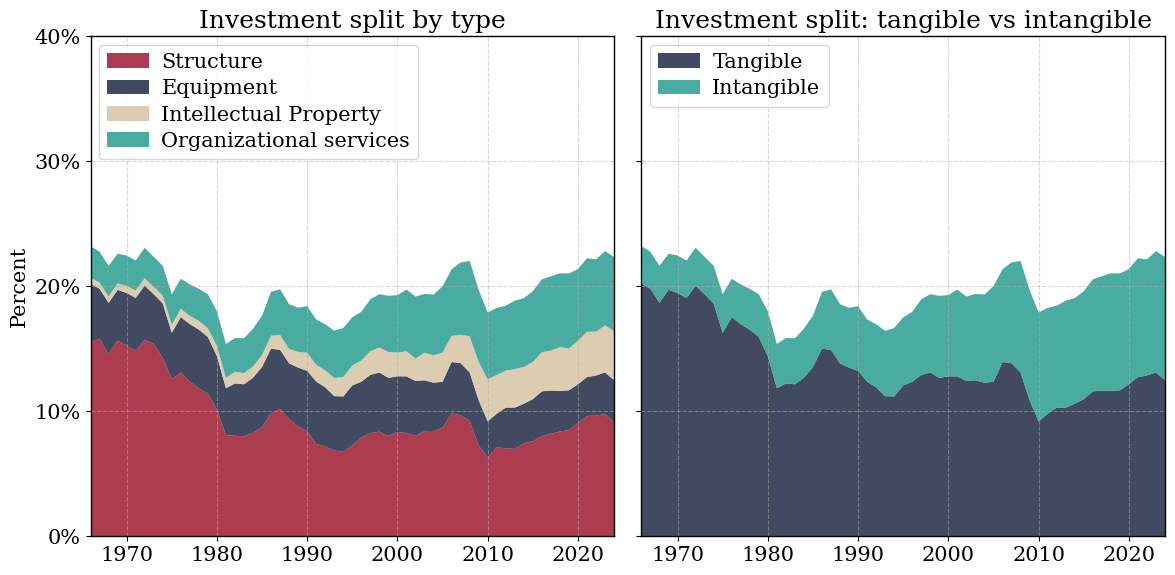

In [193]:
# --- left panel setup (unchanged) ---
order  = ["structures", "equipment", "intellectual_property", "organizational"]
labels = ["Structure", "Equipment", "Intellectual Property", "Organizational services"]

ys_left = np.vstack([wide[c].to_numpy() for c in order])
x       = wide.index.to_numpy()

colors_left = [
    "#9E1B32",  # crimson
    "#1F2A44",  # deep navy
    "#D6C3A5",  # warm sand
    "#2A9D8F",  # teal
]

# --- right panel: tangible vs intangible ---
# Use existing columns if you have them; otherwise compute them from the 4 types
if {"tangible", "intangible"}.issubset(wide.columns):
    tangible   = wide["tangible"].to_numpy()
    intangible = wide["intangible"].to_numpy()
else:
    tangible   = (wide["structures"] + wide["equipment"]).to_numpy()
    intangible = (wide["intellectual_property"] + wide["organizational"]).to_numpy()

ys_right = np.vstack([tangible, intangible])
labels_right = ["Tangible", "Intangible"]
colors_right = [
    "#1F2A44",  # tangible = deep navy
    "#2A9D8F",  # intangible = teal
]

# --- figure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# left
polys1 = ax1.stackplot(
    x, ys_left,
    colors=colors_left,
    linewidth=0.8,
    alpha=0.85
)

# right
polys2 = ax2.stackplot(
    x, ys_right,
    colors=colors_right,
    linewidth=0.8,
    alpha=0.85
)

# shared y scale + ticks (same total in both panels)
ymax = float(np.nanmax(ys_left.sum(axis=0)))
ylim_top = ymax * 1.05
for ax in (ax1, ax2):
    ax.set_ylim(0, ylim_top)
    ticks = np.arange(0, max(41, int(np.ceil(ymax / 10) * 10) + 1), 10)
    ax.set_yticks(ticks)
    ax.set_yticklabels([f"{t:.0f}%" for t in ticks])
    ax.set_xlim(x.min(), x.max())
    ax.grid(True, which="both", linestyle="--", alpha=0.5)

ax1.set_title("Investment split by type")
ax2.set_title("Investment split: tangible vs intangible")
ax1.set_ylabel("Percent")

ax1.legend(handles=polys1, labels=labels, frameon=True, loc="upper left")
ax2.legend(handles=polys2, labels=labels_right, frameon=True, loc="upper left")

plt.tight_layout()
plt.show()